In [1]:
!pip -q install scikit-learn

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Setting the seed so the results stay reproducible
def initialize_seed(seed_value=21):
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)

initialize_seed(21)

In [3]:
# Creating my own synthetic dataset with 3 input variables
def create_synthetic_data(sample_count=6500, noise_level=0.07, seed_value=21):
    rng = np.random.default_rng(seed_value)

    feature_1 = rng.uniform(-3.0, 3.0, size=(sample_count, 1))
    feature_2 = rng.uniform(-2.8, 2.8, size=(sample_count, 1))
    feature_3 = rng.uniform(-2.5, 2.5, size=(sample_count, 1))

    # This is the nonlinear equation I used to generate the target values
    target_output = (
        np.sin(1.1 * feature_1)
        + 0.4 * (feature_2 ** 2)
        - 0.6 * np.cos(1.8 * feature_3)
        + 0.25 * (feature_1 * feature_2)
        - 0.15 * (feature_2 * feature_3)
        + 0.1 * (feature_1 ** 2)
    )

    # Adding a little noise so the data feels less perfect
    target_output = target_output + rng.normal(0.0, noise_level, size=target_output.shape)

    input_data = np.concatenate([feature_1, feature_2, feature_3], axis=1).astype(np.float32)
    target_output = target_output.astype(np.float32)

    return input_data, target_output

X_data, y_data = create_synthetic_data()

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=21
)

print("Training input shape:", X_train.shape)
print("Training target shape:", y_train.shape)
print("Testing input shape:", X_test.shape)
print("Testing target shape:", y_test.shape)

Training input shape: (5200, 3)
Training target shape: (5200, 1)
Testing input shape: (1300, 3)
Testing target shape: (1300, 1)


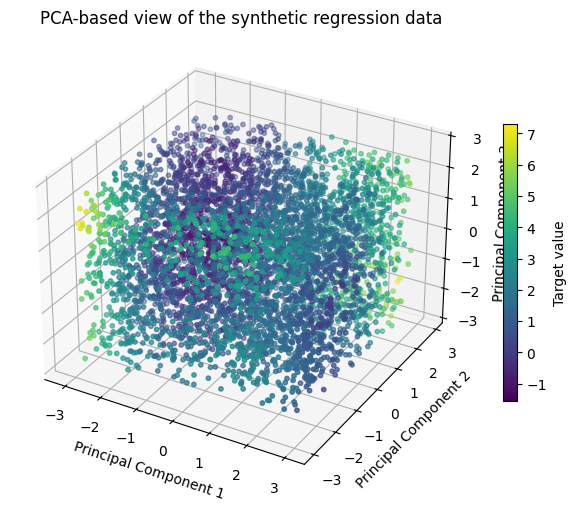

In [4]:
# A true 4D plot is not very easy to show clearly, so I used PCA here
# to reduce the input features and then used color for the target values
pca_model = PCA(n_components=3, random_state=21)
X_train_pca = pca_model.fit_transform(X_train)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

scatter_plot = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train.squeeze(),
    s=10
)

ax.set_title("PCA-based view of the synthetic regression data")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.colorbar(scatter_plot, ax=ax, shrink=0.6, label="Target value")
plt.show()

In [5]:
# Using tanh as the activation function for the hidden layers
def tanh_activation(values):
    return np.tanh(values)

# This derivative is needed during backpropagation
def tanh_derivative(pre_activation):
    activated = np.tanh(pre_activation)
    return 1.0 - activated**2

# Using tensorflow.einsum here instead of regular matrix multiplication
def einsum_dense_layer(input_array, weight_array, bias_array):
    input_tensor = tf.convert_to_tensor(input_array)
    weight_tensor = tf.convert_to_tensor(weight_array)
    bias_tensor = tf.convert_to_tensor(bias_array)

    output_tensor = tf.einsum("bi,ij->bj", input_tensor, weight_tensor) + bias_tensor
    return output_tensor.numpy()

In [6]:
# Initializing the weights and biases for all 3 layers
def initialize_parameters(input_dim=3, hidden_dim_1=48, hidden_dim_2=24, output_dim=1, seed_value=21):
    rng = np.random.default_rng(seed_value)

    def he_init(shape):
        fan_in = shape[0]
        return (rng.normal(0, 1, size=shape) * np.sqrt(2.0 / fan_in)).astype(np.float32)

    weights_1 = he_init((input_dim, hidden_dim_1))
    bias_1 = np.zeros((hidden_dim_1,), dtype=np.float32)

    weights_2 = he_init((hidden_dim_1, hidden_dim_2))
    bias_2 = np.zeros((hidden_dim_2,), dtype=np.float32)

    weights_3 = (rng.normal(0, 0.05, size=(hidden_dim_2, output_dim))).astype(np.float32)
    bias_3 = np.zeros((output_dim,), dtype=np.float32)

    return weights_1, bias_1, weights_2, bias_2, weights_3, bias_3

weights_1, bias_1, weights_2, bias_2, weights_3, bias_3 = initialize_parameters()

print("Layer 1 weights:", weights_1.shape)
print("Layer 2 weights:", weights_2.shape)
print("Layer 3 weights:", weights_3.shape)

Layer 1 weights: (3, 48)
Layer 2 weights: (48, 24)
Layer 3 weights: (24, 1)


In [7]:
# This is the forward pass through the network
def forward_pass(input_batch, weights_1, bias_1, weights_2, bias_2, weights_3, bias_3):
    z_hidden_1 = einsum_dense_layer(input_batch, weights_1, bias_1)
    a_hidden_1 = tanh_activation(z_hidden_1)

    z_hidden_2 = einsum_dense_layer(a_hidden_1, weights_2, bias_2)
    a_hidden_2 = tanh_activation(z_hidden_2)

    predicted_output = einsum_dense_layer(a_hidden_2, weights_3, bias_3)

    cache_values = (
        input_batch,
        z_hidden_1, a_hidden_1,
        z_hidden_2, a_hidden_2,
        predicted_output
    )

    return predicted_output, cache_values

In [8]:
# Using mean squared error as the main loss
def mean_squared_error(predicted_output, true_output):
    return np.mean((predicted_output - true_output) ** 2)

# I also added MAE just to get one more way to check the final predictions
def mean_absolute_error(predicted_output, true_output):
    return np.mean(np.abs(predicted_output - true_output))

In [9]:
# Doing backprop manually using the chain rule
def backward_pass(true_output, cache_values, weights_2, weights_3):
    input_batch, z_hidden_1, a_hidden_1, z_hidden_2, a_hidden_2, predicted_output = cache_values
    batch_size = input_batch.shape[0]

    # Gradient of the loss with respect to the predicted output
    gradient_output = (2.0 / batch_size) * (predicted_output - true_output)

    # Gradients for the output layer
    grad_weights_3 = a_hidden_2.T @ gradient_output
    grad_bias_3 = np.sum(gradient_output, axis=0)
    grad_a_hidden_2 = gradient_output @ weights_3.T

    # Gradients for the second hidden layer
    grad_z_hidden_2 = grad_a_hidden_2 * tanh_derivative(z_hidden_2)
    grad_weights_2 = a_hidden_1.T @ grad_z_hidden_2
    grad_bias_2 = np.sum(grad_z_hidden_2, axis=0)
    grad_a_hidden_1 = grad_z_hidden_2 @ weights_2.T

    # Gradients for the first hidden layer
    grad_z_hidden_1 = grad_a_hidden_1 * tanh_derivative(z_hidden_1)
    grad_weights_1 = input_batch.T @ grad_z_hidden_1
    grad_bias_1 = np.sum(grad_z_hidden_1, axis=0)

    return grad_weights_1, grad_bias_1, grad_weights_2, grad_bias_2, grad_weights_3, grad_bias_3

In [10]:
# Training the network using mini-batch gradient descent
def run_training(
    X_train, y_train, X_test, y_test,
    weights_1, bias_1, weights_2, bias_2, weights_3, bias_3,
    learning_rate=0.008, epochs=350, batch_size=256
):
    train_loss_history = []
    test_loss_history = []

    total_samples = X_train.shape[0]
    shuffled_indices = np.arange(total_samples)

    for epoch in range(1, epochs + 1):
        np.random.shuffle(shuffled_indices)

        for start_idx in range(0, total_samples, batch_size):
            batch_indices = shuffled_indices[start_idx:start_idx + batch_size]

            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]

            predictions, cache_values = forward_pass(
                X_batch, weights_1, bias_1, weights_2, bias_2, weights_3, bias_3
            )

            grad_weights_1, grad_bias_1, grad_weights_2, grad_bias_2, grad_weights_3, grad_bias_3 = backward_pass(
                y_batch, cache_values, weights_2, weights_3
            )

            # Updating the parameters after each batch
            weights_1 -= learning_rate * grad_weights_1
            bias_1 -= learning_rate * grad_bias_1

            weights_2 -= learning_rate * grad_weights_2
            bias_2 -= learning_rate * grad_bias_2

            weights_3 -= learning_rate * grad_weights_3
            bias_3 -= learning_rate * grad_bias_3

        # Checking train and test loss after each epoch
        train_predictions, _ = forward_pass(X_train, weights_1, bias_1, weights_2, bias_2, weights_3, bias_3)
        test_predictions, _ = forward_pass(X_test, weights_1, bias_1, weights_2, bias_2, weights_3, bias_3)

        current_train_loss = mean_squared_error(train_predictions, y_train)
        current_test_loss = mean_squared_error(test_predictions, y_test)

        train_loss_history.append(current_train_loss)
        test_loss_history.append(current_test_loss)

        if epoch % 25 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | Train MSE: {current_train_loss:.5f} | Test MSE: {current_test_loss:.5f}")

    return (
        weights_1, bias_1,
        weights_2, bias_2,
        weights_3, bias_3,
        train_loss_history, test_loss_history
    )

weights_1, bias_1, weights_2, bias_2, weights_3, bias_3, train_loss_history, test_loss_history = run_training(
    X_train, y_train, X_test, y_test,
    weights_1, bias_1, weights_2, bias_2, weights_3, bias_3
)

Epoch   1 | Train MSE: 3.01233 | Test MSE: 3.03071
Epoch  25 | Train MSE: 1.55128 | Test MSE: 1.59651
Epoch  50 | Train MSE: 0.57238 | Test MSE: 0.60393
Epoch  75 | Train MSE: 0.23401 | Test MSE: 0.25897
Epoch 100 | Train MSE: 0.13850 | Test MSE: 0.14944
Epoch 125 | Train MSE: 0.09581 | Test MSE: 0.10609
Epoch 150 | Train MSE: 0.07428 | Test MSE: 0.08099
Epoch 175 | Train MSE: 0.06197 | Test MSE: 0.06677
Epoch 200 | Train MSE: 0.05385 | Test MSE: 0.05697
Epoch 225 | Train MSE: 0.04792 | Test MSE: 0.05166
Epoch 250 | Train MSE: 0.04105 | Test MSE: 0.04356
Epoch 275 | Train MSE: 0.03734 | Test MSE: 0.03953
Epoch 300 | Train MSE: 0.03446 | Test MSE: 0.03681
Epoch 325 | Train MSE: 0.03179 | Test MSE: 0.03339
Epoch 350 | Train MSE: 0.02935 | Test MSE: 0.03061


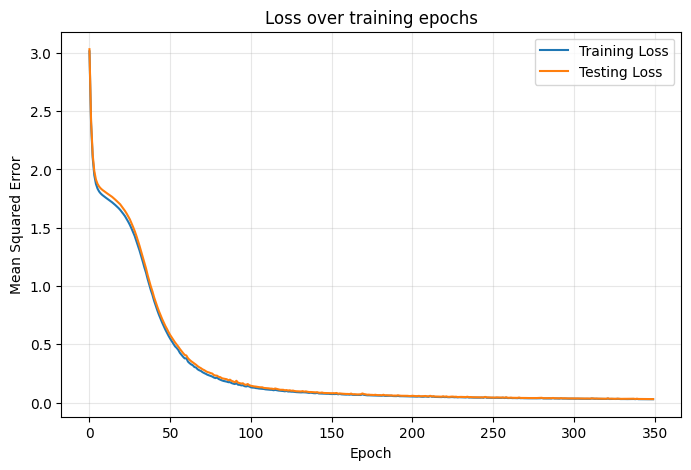

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Testing Loss")
plt.title("Loss over training epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Final Test MSE: 0.03061
Final Test MAE: 0.13759


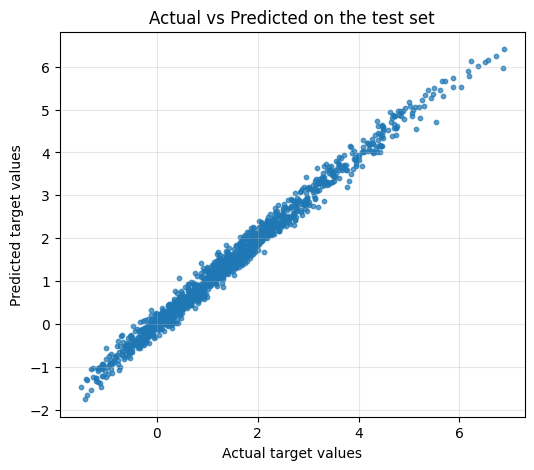

In [12]:
final_test_predictions, _ = forward_pass(
    X_test, weights_1, bias_1, weights_2, bias_2, weights_3, bias_3
)

final_mse = mean_squared_error(final_test_predictions, y_test)
final_mae = mean_absolute_error(final_test_predictions, y_test)

print("Final Test MSE:", round(final_mse, 5))
print("Final Test MAE:", round(final_mae, 5))

plt.figure(figsize=(6, 5))
plt.scatter(y_test.squeeze(), final_test_predictions.squeeze(), s=10, alpha=0.7)
plt.xlabel("Actual target values")
plt.ylabel("Predicted target values")
plt.title("Actual vs Predicted on the test set")
plt.grid(alpha=0.3)
plt.show()

### Final Observation
In this notebook, I built a 3-layer neural network from scratch for a nonlinear regression problem. I used manual forward propagation and backpropagation, and the model was able to learn the overall pattern in the synthetic data as the training loss kept decreasing over time.